# Phase 3 — Notebook 04 : Modélisation & Comparaison des stratégies de rééquilibrage

**Objectifs de ce notebook :**
1. Entraîner 4 familles de modèles (Logistic Regression, Decision Tree, XGBoost, MLP)
2. Comparer 3 stratégies de gestion du déséquilibre (baseline, SMOTE, undersampling)
3. Produire un tableau comparatif 4×3 = 12 configurations
4. Identifier la meilleure combinaison modèle × stratégie pour le tuning (notebook 05)

**Métrique principale :** Recall (cible ≥ 0.80)  
**Métriques secondaires :** Precision (≥ 0.50), F1 (≥ 0.65), PR-AUC  
**Protocole :** StratifiedKFold(n_splits=5) sur le jeu d'entraînement, random_state=42 partout

## 0. Imports & configuration

In [11]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    recall_score, precision_score, f1_score,
    average_precision_score, make_scorer
)

# XGBoost
from xgboost import XGBClassifier

# imbalanced-learn  ← obligatoire pour SMOTE dans un pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Imports OK')

Imports OK


## 1. Chargement des données prétraitées

In [12]:
import os 
current_path = os.getcwd()
DATA_DIR = Path(current_path) / 'modeling' / 'data' / 'processed'

train_df = pd.read_csv(DATA_DIR / 'train.csv')
val_df   = pd.read_csv(DATA_DIR / 'validation.csv')

TARGET = 'gdp_shock'
FEATURES = [c for c in train_df.columns if c != TARGET]

X_train = train_df[FEATURES].values
y_train = train_df[TARGET].values

X_val = val_df[FEATURES].values
y_val = val_df[TARGET].values

print(f'Train : {X_train.shape}  |  Shocks : {y_train.mean():.2%}')
print(f'Val   : {X_val.shape}    |  Shocks : {y_val.mean():.2%}')
print(f'Nombre de features : {len(FEATURES)}')

Train : (7364, 29)  |  Shocks : 8.28%
Val   : (1578, 29)    |  Shocks : 8.24%
Nombre de features : 29


## 2. Définition des modèles et des stratégies

### Pourquoi `imblearn.pipeline.Pipeline` et non `sklearn.pipeline.Pipeline` ?

Avec `imblearn.Pipeline`, le rééchantillonnage (SMOTE, undersampling) est appliqué **uniquement sur les données d'entraînement de chaque fold** lors de la validation croisée. Il n'est jamais appliqué aux données de validation ou de test. Avec `sklearn.Pipeline`, SMOTE serait ignoré car il n'est pas un `Transformer` sklearn standard.

In [13]:
# ── Calcul du scale_pos_weight pour XGBoost (ratio majoritaire/minoritaire)
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count
print(f'scale_pos_weight XGBoost : {scale_pos_weight:.2f}')

# ── Définition des 4 modèles de base
# Chaque modèle est instancié avec class_weight='balanced' quand disponible
# pour la stratégie baseline (sans rééchantillonnage externe)

MODELS = {
    'LogisticRegression': LogisticRegression(
        class_weight='balanced',
        max_iter=5000,
        solver='saga',          # saga supporte l1 et l2, bon sur grands datasets
        random_state=RANDOM_STATE
    ),
    'DecisionTree': DecisionTreeClassifier(
        class_weight='balanced',
        random_state=RANDOM_STATE
    ),
    'XGBoost': XGBClassifier(
        scale_pos_weight=scale_pos_weight,  # gestion native du déséquilibre
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        verbosity=0
    ),
    'MLP': MLPClassifier(
        hidden_layer_sizes=(128, 64),
        max_iter=500,
        early_stopping=True,
        random_state=RANDOM_STATE
    ),
}

# ── Définition des 3 stratégies de rééquilibrage
# None  → pas de rééchantillonnage (class_weight gère le déséquilibre)
# SMOTE → oversampling de la classe minoritaire par interpolation
# RUS   → undersampling aléatoire de la classe majoritaire

STRATEGIES = {
    'Baseline (class_weight)': None,
    'SMOTE': SMOTE(random_state=RANDOM_STATE),
    'Undersampling': RandomUnderSampler(random_state=RANDOM_STATE),
}

print('Modèles et stratégies définis.')

scale_pos_weight XGBoost : 11.07
Modèles et stratégies définis.


## 3. Protocole de validation croisée

- `StratifiedKFold(n_splits=5)` : préserve le ratio de chocs dans chaque fold
- Métriques calculées : Recall, Precision, F1, PR-AUC
- On reporte la **moyenne ± écart-type** sur les 5 folds

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Scorers personnalisés (pos_label=1 = classe choc)
scoring = {
    'recall':    make_scorer(recall_score,    pos_label=1, zero_division=0),
    'precision': make_scorer(precision_score, pos_label=1, zero_division=0),
    'f1':        make_scorer(f1_score,        pos_label=1, zero_division=0),
    'pr_auc':    make_scorer(average_precision_score, response_method='predict_proba'),
}

print('CV configuré : StratifiedKFold(n_splits=5)')

CV configuré : StratifiedKFold(n_splits=5)


## 4. Entraînement des 12 configurations (4 modèles × 3 stratégies)

In [15]:
results = []

for model_name, model in MODELS.items():
    for strategy_name, sampler in STRATEGIES.items():
        print(f'  → {model_name:20s} | {strategy_name}', end=' ... ')

        # Construction du pipeline imblearn
        if sampler is not None:
            # Avec rééchantillonnage : SMOTE ou undersampling avant le modèle
            pipeline = ImbPipeline([
                ('sampler', sampler),
                ('model',   model)
            ])
        else:
            # Baseline : pipeline sans rééchantillonnage
            # On utilise quand même ImbPipeline pour la cohérence
            pipeline = ImbPipeline([
                ('model', model)
            ])

        # Validation croisée
        cv_scores = cross_validate(
            pipeline, X_train, y_train,
            cv=cv,
            scoring=scoring,
            n_jobs=-1,
            error_score='raise'
        )

        row = {
            'Modèle':    model_name,
            'Stratégie': strategy_name,
            'Recall_mean':    cv_scores['test_recall'].mean(),
            'Recall_std':     cv_scores['test_recall'].std(),
            'Precision_mean': cv_scores['test_precision'].mean(),
            'Precision_std':  cv_scores['test_precision'].std(),
            'F1_mean':        cv_scores['test_f1'].mean(),
            'F1_std':         cv_scores['test_f1'].std(),
            'PR_AUC_mean':    cv_scores['test_pr_auc'].mean(),
            'PR_AUC_std':     cv_scores['test_pr_auc'].std(),
        }
        results.append(row)
        print(f"Recall={row['Recall_mean']:.3f} ± {row['Recall_std']:.3f}")

results_df = pd.DataFrame(results)
print('\n12 configurations évaluées.')

  → LogisticRegression   | Baseline (class_weight) ... Recall=0.523 ± 0.048
  → LogisticRegression   | SMOTE ... Recall=0.561 ± 0.049
  → LogisticRegression   | Undersampling ... Recall=0.572 ± 0.036
  → DecisionTree         | Baseline (class_weight) ... Recall=0.182 ± 0.006
  → DecisionTree         | SMOTE ... Recall=0.246 ± 0.034
  → DecisionTree         | Undersampling ... Recall=0.633 ± 0.047
  → XGBoost              | Baseline (class_weight) ... Recall=0.257 ± 0.026
  → XGBoost              | SMOTE ... Recall=0.374 ± 0.027
  → XGBoost              | Undersampling ... Recall=0.808 ± 0.033
  → MLP                  | Baseline (class_weight) ... Recall=0.048 ± 0.053
  → MLP                  | SMOTE ... Recall=0.308 ± 0.052
  → MLP                  | Undersampling ... Recall=0.533 ± 0.049

12 configurations évaluées.


## 5. Tableau comparatif des 12 configurations

In [16]:
# Formatage : afficher mean ± std pour chaque métrique
display_df = results_df.copy()
for metric in ['Recall', 'Precision', 'F1', 'PR_AUC']:
    display_df[metric] = (
        display_df[f'{metric}_mean'].map('{:.3f}'.format)
        + ' ± '
        + display_df[f'{metric}_std'].map('{:.3f}'.format)
    )

table = display_df[['Modèle', 'Stratégie', 'Recall', 'Precision', 'F1', 'PR_AUC']]
print('=== Tableau comparatif — 12 configurations ===')
print(table.to_string(index=False))

=== Tableau comparatif — 12 configurations ===
            Modèle               Stratégie        Recall     Precision            F1        PR_AUC
LogisticRegression Baseline (class_weight) 0.523 ± 0.048 0.189 ± 0.011 0.277 ± 0.017 0.238 ± 0.033
LogisticRegression                   SMOTE 0.561 ± 0.049 0.181 ± 0.008 0.273 ± 0.015 0.236 ± 0.031
LogisticRegression           Undersampling 0.572 ± 0.036 0.165 ± 0.018 0.256 ± 0.024 0.234 ± 0.038
      DecisionTree Baseline (class_weight) 0.182 ± 0.006 0.181 ± 0.012 0.181 ± 0.008 0.101 ± 0.002
      DecisionTree                   SMOTE 0.246 ± 0.034 0.183 ± 0.009 0.209 ± 0.018 0.108 ± 0.006
      DecisionTree           Undersampling 0.633 ± 0.047 0.140 ± 0.013 0.229 ± 0.021 0.120 ± 0.012
           XGBoost Baseline (class_weight) 0.257 ± 0.026 0.247 ± 0.018 0.252 ± 0.020 0.232 ± 0.019
           XGBoost                   SMOTE 0.374 ± 0.027 0.194 ± 0.014 0.255 ± 0.017 0.228 ± 0.012
           XGBoost           Undersampling 0.808 ± 0.033 0.137

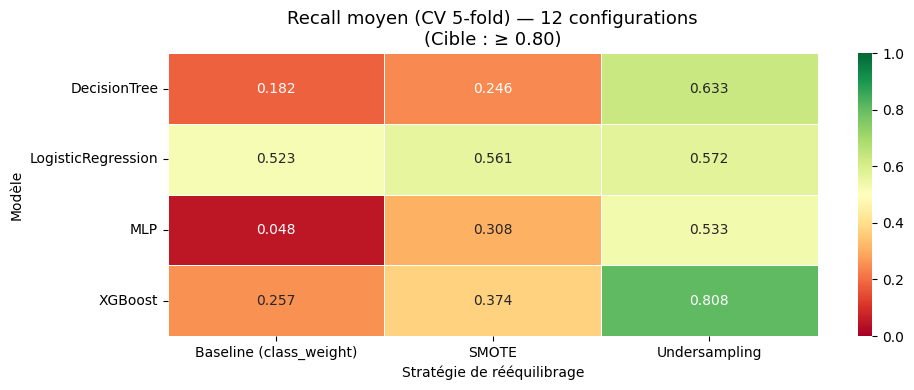

In [17]:
# Heatmap du Recall moyen (métrique principale)
pivot_recall = results_df.pivot(index='Modèle', columns='Stratégie', values='Recall_mean')

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    pivot_recall, annot=True, fmt='.3f', cmap='RdYlGn',
    vmin=0, vmax=1, linewidths=0.5, ax=ax
)
ax.set_title('Recall moyen (CV 5-fold) — 12 configurations\n(Cible : ≥ 0.80)', fontsize=13)
ax.set_xlabel('Stratégie de rééquilibrage')
ax.set_ylabel('Modèle')
plt.tight_layout()
plt.savefig('../models/heatmap_recall.png', dpi=150)
plt.show()

## 6. Sélection de la meilleure combinaison

In [18]:
# Critère de sélection : maximiser le Recall moyen
# En cas d'égalité, on favorise le F1 le plus élevé
best_idx = results_df.sort_values(
    ['Recall_mean', 'F1_mean'], ascending=False
).index[0]

best = results_df.loc[best_idx]
print('=== Meilleure combinaison sélectionnée ===')
print(f"  Modèle    : {best['Modèle']}")
print(f"  Stratégie : {best['Stratégie']}")
print(f"  Recall    : {best['Recall_mean']:.3f} ± {best['Recall_std']:.3f}")
print(f"  Precision : {best['Precision_mean']:.3f} ± {best['Precision_std']:.3f}")
print(f"  F1        : {best['F1_mean']:.3f} ± {best['F1_std']:.3f}")
print(f"  PR-AUC    : {best['PR_AUC_mean']:.3f} ± {best['PR_AUC_std']:.3f}")
print(f"\n→ Cette combinaison sera optimisée dans le notebook 05_tuning.ipynb")

=== Meilleure combinaison sélectionnée ===
  Modèle    : XGBoost
  Stratégie : Undersampling
  Recall    : 0.808 ± 0.033
  Precision : 0.137 ± 0.007
  F1        : 0.235 ± 0.011
  PR-AUC    : 0.247 ± 0.018

→ Cette combinaison sera optimisée dans le notebook 05_tuning.ipynb


In [19]:
# Sauvegarde des résultats pour référence dans les notebooks suivants
results_df.to_csv('../models/modeling_results.csv', index=False)
print('Résultats sauvegardés → models/modeling_results.csv')

Résultats sauvegardés → models/modeling_results.csv
